# Téléchargement du dataset Kaggle avec kagglehub

Notebook pour télécharger et vérifier un dataset Kaggle avec kagglehub.

## Installer et importer kagglehub

Installer la dépendance si nécessaire et importer kagglehub dans le notebook.

In [ ]:
# Installer kagglehub si nécessaire puis importer
try:
    import kagglehub  # noqa: F401
except ModuleNotFoundError:
    # Installation dans l'environnement du notebook
    %pip install kagglehub
    import kagglehub

## Télécharger le dataset avec kagglehub

Utiliser `kagglehub.dataset_download` avec l’ID du dataset et afficher le chemin renvoyé.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bmadushanirodrigo/fracture-multi-region-x-ray-data")

print("Path to dataset files:", path)

Path to dataset files: /home/florian/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2


## Lister et vérifier les fichiers téléchargés

Lister les fichiers et dossiers sous le chemin téléchargé pour vérifier le contenu.

In [ ]:
from pathlib import Path

base_path = Path(path)

# Lister le contenu immédiat
for p in sorted(base_path.iterdir()):
    print(p.name)

Bone_Fracture_Binary_Classification
README.dataset.txt


## Aperçu rapide de la structure du dossier

Afficher quelques exemples de fichiers et sous-dossiers pour valider la structure.

In [ ]:
# Afficher un aperçu de quelques fichiers/sous-dossiers
all_items = sorted(base_path.rglob("*"))

print("Total items:", len(all_items))
print("Aperçu (10 premiers):")
for p in all_items[:10]:
    rel = p.relative_to(base_path)
    print(rel)

Total items: 10790
Aperçu (10 premiers):
Bone_Fracture_Binary_Classification
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/0.jpg
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/0.png
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/00001.jpg
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/00001.png
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/00004541.jpg
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/00004541.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

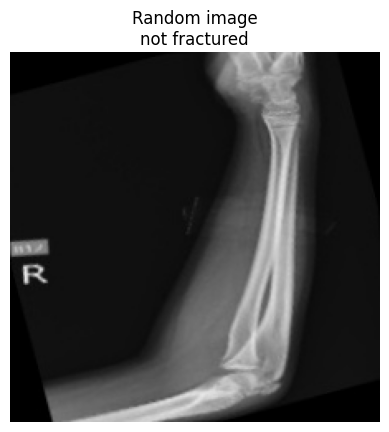

In [ ]:
import random

# Filtrer uniquement les fichiers image (png, jpg, jpeg)
image_candidates = [p for p in all_items if p.suffix.lower() in {'.png', '.jpg', '.jpeg'} and p.is_file()]

random_img_path = random.choice(image_candidates)
img = mpimg.imread(str(random_img_path))

plt.imshow(img)
plt.title(f"Random image\n{random_img_path.parent.name}")
plt.axis('off')
plt.show()

# Normalisation du dataset

In [ ]:
import numpy as np

try:
    import pandas as pd
except ModuleNotFoundError:
    %pip install pandas
    import pandas as pd

### Nettoyage du dataset : ne garder que les fichiers images valides (png, jpg, jpeg)

In [ ]:
import hashlib

def image_pixel_hash(filepath):
    """Hash basé sur les pixels redimensionnés pour détecter les vrais doublons."""
    try:
        img = mpimg.imread(str(filepath))
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8)
        h, w = img.shape[:2]
        row_idx = np.linspace(0, h - 1, 32).astype(int)
        col_idx = np.linspace(0, w - 1, 32).astype(int)
        small = img[np.ix_(row_idx, col_idx)]
        return hashlib.md5(small.tobytes()).hexdigest()
    except:
        return None

# Déduplication par hash de pixels (pas par nom de fichier)
seen_hashes = set()
cleaned_image_files = []
dup_count = 0
for p in image_candidates:
    h = image_pixel_hash(p)
    if h is None:
        continue  # image corrompue
    if h not in seen_hashes:
        seen_hashes.add(h)
        cleaned_image_files.append(p)
    else:
        dup_count += 1

print(f"Images avant déduplication : {len(image_candidates)}")
print(f"Doublons pixel-identiques supprimés : {dup_count}")
print(f"Images uniques restantes : {len(cleaned_image_files)}")

Images avant déduplication : 10778
Doublons pixel-identiques supprimés : 6804
Images uniques restantes : 3974


In [ ]:
def is_valid_image(filepath):
    try:
        img = mpimg.imread(str(filepath))
        if img.ndim < 2:
            return False
        return True
    except:
        return False

In [ ]:
import os

def clean_corrupted_images(image_files):
    valid_images = []
    corrupted_count = 0

    for img_path in image_files:
        try:
            img = mpimg.imread(str(img_path))
            if img.ndim < 2:
                raise ValueError("Not a valid image array")
            valid_images.append(img_path)
        except Exception as e:
            print(f"Corrupted image: {img_path} — {e}")
            corrupted_count += 1
            os.remove(img_path)

    total_images = len(image_files)
    print(f"Total images: {total_images}")
    print(f"Corrupted images: {corrupted_count}")
    print(f"Valid images kept: {len(valid_images)}")
    print(f"Corruption rate: {corrupted_count / total_images * 100:.2f}%")

    return valid_images

cleaned_image_files = clean_corrupted_images(cleaned_image_files)

Total images: 3974
Corrupted images: 0
Valid images kept: 3974
Corruption rate: 0.00%


### Exemple : créer un DataFrame utilisable pour l'IA (chemin + label)

In [ ]:
# Extraire le label (fractured / not fractured)
def get_label(path):
    return path.parent.name

df = pd.DataFrame({
    "filepath": [str(p) for p in cleaned_image_files],
    "label": [get_label(p) for p in cleaned_image_files],
})

print(df.head())
print(f"\nRépartition par label :")
print(df['label'].value_counts())

                                            filepath      label
0  /home/florian/.cache/kagglehub/datasets/bmadus...  fractured
1  /home/florian/.cache/kagglehub/datasets/bmadus...  fractured
2  /home/florian/.cache/kagglehub/datasets/bmadus...  fractured
3  /home/florian/.cache/kagglehub/datasets/bmadus...  fractured
4  /home/florian/.cache/kagglehub/datasets/bmadus...  fractured

Répartition par label :
label
not fractured    2291
fractured        1683
Name: count, dtype: int64


## Préparation des données pour l'entraînement

Séparation du DataFrame en ensembles d'entraînement, validation et test, puis préparation des transformations éventuelles.

In [ ]:
try:
    from sklearn.model_selection import train_test_split
except ModuleNotFoundError:
    %pip install scikit-learn
    from sklearn.model_selection import train_test_split

# Split propre sur les images UNIQUES (plus de leak possible)
# 70% train / 15% val / 15% test
df_train, df_temp = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp['label'], random_state=42)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 2781 | Val: 596 | Test: 597


### Préparer des transformations d'images

Exemple : redimensionnement, normalisation, augmentation, etc. (à adapter selon le framework utilisé pour l'entraînement).

In [ ]:
IMG_SIZE = (64, 64)

def resize_image(path, size=IMG_SIZE):
    """Charge et redimensionne une image avec numpy (nearest neighbor)."""
    img = mpimg.imread(str(path))
    # Gérer niveaux de gris → RGB
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    # Gérer RGBA → RGB
    if img.shape[-1] == 4:
        img = img[:, :, :3]
    # Normaliser en float32 [0, 1]
    if img.dtype == np.uint8:
        img = img.astype(np.float32) / 255.0
    # Redimensionnement nearest-neighbor
    h, w = img.shape[:2]
    th, tw = size
    row_idx = np.linspace(0, h - 1, th).astype(int)
    col_idx = np.linspace(0, w - 1, tw).astype(int)
    return img[np.ix_(row_idx, col_idx)]

# Training du dataset

### Entraînement d'un modèle de classification avec Scikit-learn

Nous allons charger les images, les redimensionner en vecteurs aplatis, puis entraîner un RandomForestClassifier.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
def load_and_preprocess(filepath, size=IMG_SIZE):
    """Charge une image, la redimensionne et l'aplatit en vecteur."""
    img = mpimg.imread(str(filepath))
    # Gérer niveaux de gris → RGB
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    # Gérer RGBA → RGB
    if img.shape[-1] == 4:
        img = img[:, :, :3]
    # Normaliser en float32 [0, 1]
    if img.dtype == np.uint8:
        img = img.astype(np.float32) / 255.0
    elif img.max() > 1.0:
        img = img / 255.0
    # Redimensionnement nearest-neighbor
    h, w = img.shape[:2]
    th, tw = size
    row_idx = np.linspace(0, h - 1, th).astype(int)
    col_idx = np.linspace(0, w - 1, tw).astype(int)
    img = img[np.ix_(row_idx, col_idx)]
    return img.flatten()

def load_dataset(df):
    """Charge toutes les images d'un DataFrame en matrices numpy."""
    X, y = [], []
    for _, row in df.iterrows():
        try:
            vec = load_and_preprocess(row['filepath'])
            X.append(vec)
            y.append(row['label'])
        except Exception:
            pass  # skip bad images
    return np.array(X), np.array(y)

print("Chargement des données d'entraînement...")
X_train, y_train = load_dataset(df_train)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

print("Chargement des données de validation...")
X_val, y_val = load_dataset(df_val)
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")

print("Chargement des données de test...")
X_test, y_test = load_dataset(df_test)
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Chargement des données d'entraînement...
X_train: (2781, 12288), y_train: (2781,)
Chargement des données de validation...
X_val: (596, 12288), y_val: (596,)
Chargement des données de test...
X_test: (597, 12288), y_test: (597,)


In [ ]:
# Entraînement d'un RandomForestClassifier
print("Entraînement du modèle RandomForest...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Évaluation sur la validation
val_acc = model.score(X_val, y_val)
print(f"Validation accuracy: {val_acc:.3f}")

Entraînement du modèle RandomForest...
Validation accuracy: 0.971


In [ ]:
# Évaluation sur le test
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.3f}")

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Test accuracy: 0.970

Rapport de classification :
               precision    recall  f1-score   support

    fractured       0.96      0.97      0.96       253
not fractured       0.98      0.97      0.97       344

     accuracy                           0.97       597
    macro avg       0.97      0.97      0.97       597
 weighted avg       0.97      0.97      0.97       597



1. VÉRIFICATION DU DATA LEAK
Hashes train : 2781
Doublons train↔test : 0 / 597
✅ Aucun data leak détecté !

2. EXEMPLES D'IMAGES PAR CLASSE


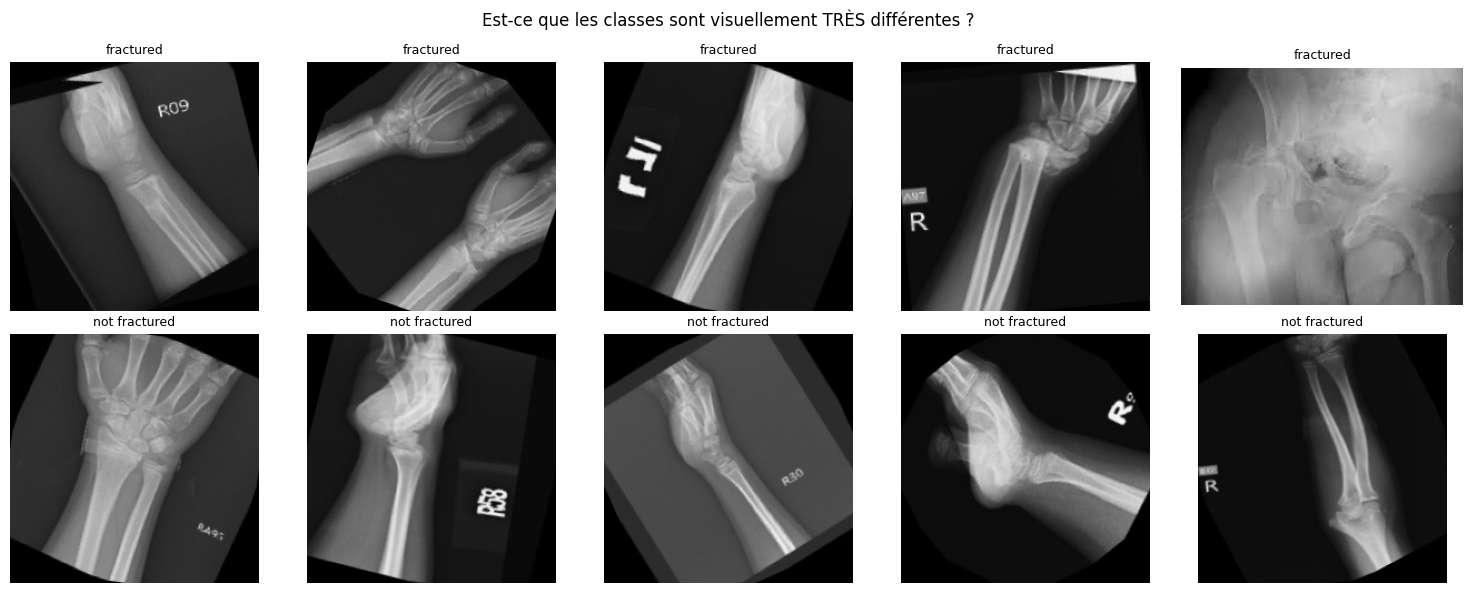


3. STATISTIQUES SIMPLES PAR CLASSE (artefacts ?)
  fractured       — Luminosité moyenne : 68.9 ± 27.5
  not fractured   — Luminosité moyenne : 58.9 ± 18.3

4. BASELINE : RandomForest sur des PIXELS ALÉATOIRES
Accuracy avec features ALÉATOIRES : 0.529
Accuracy avec features RÉELLES    : 0.970
✅ Le modèle random ≈ 50% → les features réelles sont informatives

5. CARTE D'IMPORTANCE DES FEATURES


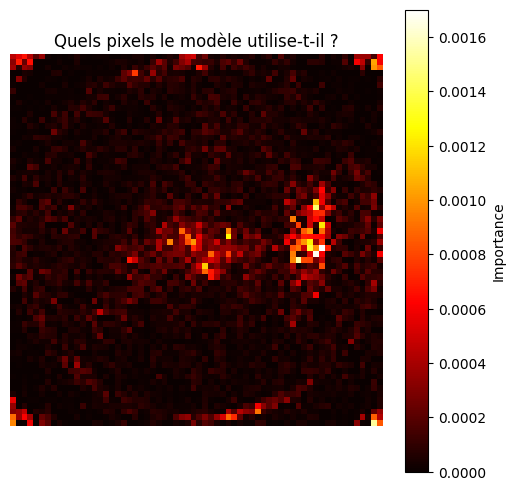

In [ ]:
# ===== DIAGNOSTIC COMPLET =====

# 1) Vérifier qu'il n'y a plus de leak entre train et test
print("=" * 50)
print("1. VÉRIFICATION DU DATA LEAK")
print("=" * 50)

train_hashes = set()
for _, row in df_train.iterrows():
    h = image_pixel_hash(row['filepath'])
    if h:
        train_hashes.add(h)

leak = 0
for _, row in df_test.iterrows():
    h = image_pixel_hash(row['filepath'])
    if h and h in train_hashes:
        leak += 1

print(f"Hashes train : {len(train_hashes)}")
print(f"Doublons train↔test : {leak} / {len(df_test)}")
if leak == 0:
    print("✅ Aucun data leak détecté !")
else:
    print(f"🚨 LEAK ENCORE PRÉSENT : {leak} images")

# 2) Afficher des exemples d'images de chaque classe
print("\n" + "=" * 50)
print("2. EXEMPLES D'IMAGES PAR CLASSE")
print("=" * 50)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, label in enumerate(['fractured', 'not fractured']):
    samples = df_test[df_test['label'] == label].sample(5, random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = mpimg.imread(row['filepath'])
        axes[i, j].imshow(img, cmap='gray' if img.ndim == 2 else None)
        axes[i, j].set_title(label, fontsize=9)
        axes[i, j].axis('off')
plt.suptitle("Est-ce que les classes sont visuellement TRÈS différentes ?")
plt.tight_layout()
plt.show()

# 3) Vérifier si le modèle n'exploite pas des artefacts (luminosité moyenne, taille...)
print("\n" + "=" * 50)
print("3. STATISTIQUES SIMPLES PAR CLASSE (artefacts ?)")
print("=" * 50)

for label in ['fractured', 'not fractured']:
    subset = df_test[df_test['label'] == label]
    means = []
    for _, row in subset.iterrows():
        try:
            img = mpimg.imread(row['filepath'])
            if img.dtype != np.uint8:
                img = (img * 255).astype(np.uint8)
            means.append(img.mean())
        except:
            pass
    print(f"  {label:15s} — Luminosité moyenne : {np.mean(means):.1f} ± {np.std(means):.1f}")

# 4) Test avec des features aléatoires (baseline)
print("\n" + "=" * 50)
print("4. BASELINE : RandomForest sur des PIXELS ALÉATOIRES")
print("=" * 50)

rng = np.random.RandomState(42)
X_train_random = rng.rand(*X_train.shape).astype(np.float32)
X_test_random = rng.rand(*X_test.shape).astype(np.float32)

model_random = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_random.fit(X_train_random, y_train)
random_acc = model_random.score(X_test_random, y_test)
print(f"Accuracy avec features ALÉATOIRES : {random_acc:.3f}")
print(f"Accuracy avec features RÉELLES    : {test_acc:.3f}")

if random_acc > 0.55:
    print("🚨 Le modèle random fait mieux que le hasard → possible problème de labels")
else:
    print("✅ Le modèle random ≈ 50% → les features réelles sont informatives")

# 5) Feature importance : le modèle utilise-t-il des zones concentrées ?
print("\n" + "=" * 50)
print("5. CARTE D'IMPORTANCE DES FEATURES")
print("=" * 50)

importances = model.feature_importances_.reshape(*IMG_SIZE, 3).mean(axis=2)
plt.figure(figsize=(6, 6))
plt.imshow(importances, cmap='hot')
plt.colorbar(label='Importance')
plt.title("Quels pixels le modèle utilise-t-il ?")
plt.axis('off')
plt.show()